# Predicting reputation of Stats Stack Exchange users

### Introduction

Stats Stack Exchange is a popular Q&A platform, where users raise questions primarily concerning statistics, data science and computer engineering. These Questions are answered by other users. To drive engagement and develop a sense of community users can earn a reputation via various means. The objective of this notebook is to predict users' reputation given their interaction with the platform and other users.

### 1. Setup

In this section, we:
- Import required libraries.
- Create a getML project.
- Download the "H&M" dataset from CTU data repository.

In [1]:
import getml
from ctu.utils.data import load_ctu_dataset
import matplotlib.pyplot as plt

# Launch getML engine and set project.
getml.set_project("stats")

# Download dataset and task from CTU data repository.
users, peripheral = load_ctu_dataset("stats")

(
    badges,
    comments,
    post_history,
    post_links,
    posts,
    tags,
    votes,
) = peripheral.values()

Output()

Connected to project 'stats'.

Analyzing schema:   0%|          | 0/8 [00:00<?, ?it/s]

Building data:   0%|          | 0/8 [00:00<?, ?it/s]

---
### 2. Data Preparation

 __Annotating Data__
 
Define the  [roles](https://getml.com/latest/user_guide/concepts/annotating_data/) for users, comments, badges , votes and posts tables.
These roles help getML understand how to process each column.

Roles are set based on the insights gained from the entity relationship diagram below.

Reputation is the target column for a regression task.
<h4>
  <details open>
     <summary>ER Diagram</summary>
       <img src="https://relational.fel.cvut.cz/assets/img/datasets-generated/stats.svg" alt="stats ER Diagram">
   </details>
</h4>

In [2]:
users.save()

for name, df in peripheral.items():
    df.save()

In [3]:
users.load()

users.set_role("Reputation", getml.data.roles.target)
users.set_role(["CreationDate", "LastAccessDate"], getml.data.roles.time_stamp)
users.set_role(["Id"], getml.data.roles.join_key)
users.set_role(["Views", "UpVotes", "DownVotes"], getml.data.roles.numerical)

users.drop(users.roles.unused)
users

name,CreationDate,LastAccessDate,Id,Reputation,Views,UpVotes,DownVotes,DisplayName,WebsiteUrl,Location,AboutMe,AccountId,Age,ProfileImageUrl,split
role,time_stamp,time_stamp,join_key,target,numerical,numerical,numerical,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string
unit,"time stamp, comparison only","time stamp, comparison only",,,,,,,,,,,,,
0,2010-07-19 06:55:26,2010-07-19 06:55:26,-1,1,0,5007,1920,Community,http://meta.stackexchange.com/,on the server farm,"<p>Hi, I'm not really a person.<...",-1,NULL,NULL,train
1,2010-07-19 14:01:36,2013-11-12 22:07:23,2,101,25,3,0,Geoff Dalgas,http://stackoverflow.com,"Corvallis, OR",<p>Developer on the StackOverflo...,2,37,NULL,train
2,2010-07-19 15:34:50,2014-08-08 06:42:58,3,101,22,19,0,Jarrod Dixon,http://stackoverflow.com,"New York, NY","<p><a href=""http://blog.stackove...",3,35,NULL,train
3,2010-07-19 19:03:27,2014-01-02 09:31:02,4,101,11,0,0,Emmett,http://minesweeperonline.com,"San Francisco, CA",<p>currently at a startup in SF<...,1998,28,http://i.stack.imgur.com/d1oHX.j...,train
4,2010-07-19 19:03:57,2014-08-13 00:23:47,5,6792,1145,662,5,Shane,http://www.statalgo.com,"New York, NY",<p>Quantitative researcher focus...,54503,35,NULL,train
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
40320,2014-09-13 21:03:50,2014-09-13 21:18:52,55743,1,0,0,0,AussieMeg,NULL,NULL,NULL,5026902,NULL,http://graph.facebook.com/665821...,train
40321,2014-09-13 21:39:30,2014-09-13 21:39:30,55744,6,1,0,0,Mia Maria,NULL,NULL,NULL,5026998,NULL,NULL,train


In [ ]:
comments.load()

comments.set_role(["Id", "PostId", "UserId"], getml.data.roles.join_key)
comments.set_role("CreationDate", getml.data.roles.time_stamp)
comments.set_role(["Score"], getml.data.roles.numerical)

comments.drop(comments.roles.unused)

comments

name,CreationDate,Id,PostId,UserId,Score,Text,UserDisplayName
role,time_stamp,join_key,join_key,join_key,numerical,unused_string,unused_string
unit,"time stamp, comparison only",,,,,,
0,2010-07-19 19:15:52,1,3,13,5,Could be a poster child fo argum...,NULL
1,2010-07-19 19:16:14,2,5,13,0,"Yes, R is nice- but WHY is it 'v...",NULL
2,2010-07-19 19:18:54,3,9,13,0,Again- why? How would I convinc...,NULL
3,2010-07-19 19:19:56,4,5,37,11,"It's mature, well supported, and...",NULL
4,2010-07-19 19:20:28,5,3,5,1,"Define ""valuable""...",NULL
,...,...,...,...,...,...,...
174300,2014-09-14 01:45:11,221288,52312,13564,0,You and Bogdanovist are in disag...,NULL
174301,2014-09-14 01:45:19,221289,115376,55746,0,"@gung goal would be to say ""Vide...",NULL


In [5]:
badges.set_role(["Id", "UserId"], getml.data.roles.join_key)
badges.set_role("Date", getml.data.roles.time_stamp)
badges.set_role("Name", getml.data.roles.categorical)

badges

name,Date,Id,UserId,Name
role,time_stamp,join_key,join_key,categorical
unit,"time stamp, comparison only",,,
0,2010-07-19 19:39:07,1,5,Teacher
1,2010-07-19 19:39:07,2,6,Teacher
2,2010-07-19 19:39:07,3,8,Teacher
3,2010-07-19 19:39:07,4,23,Teacher
4,2010-07-19 19:39:07,5,36,Teacher
,...,...,...,...
79846,2014-09-13 23:25:21,92236,55744,Student
79847,2014-09-14 00:09:35,92237,1118,Nice Answer


In [6]:
posts.load()

posts.add(posts.LastEditorUserId, name="LastEditorUserIdNum", role=getml.data.roles.numerical)
posts.set_role(["Id", "AcceptedAnswerId", "OwnerUserId", "LastEditorUserId"], getml.data.roles.join_key)
posts.set_role(["Score", "ViewCount", "AnswerCount", "CommentCount", "FavoriteCount"], getml.data.roles.numerical)
posts.set_role(["PostTypeId"], getml.data.roles.categorical)

posts.drop(posts.roles.unused)

posts

name,Id,AcceptedAnswerId,OwnerUserId,LastEditorUserId,PostTypeId,LastEditorUserIdNum,Score,ViewCount,AnswerCount,CommentCount,FavoriteCount,CreaionDate,Body,LasActivityDate,Title,Tags,LastEditDate,CommunityOwnedDate,ParentId,ClosedDate,OwnerDisplayName,LastEditorDisplayName
role,join_key,join_key,join_key,join_key,categorical,numerical,numerical,numerical,numerical,numerical,numerical,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string,unused_string
0,1,15,8,NULL,1,nan,23,1278,5,1,14,2010-07-19 19:12:12.000000,<p>How should I elicit prior dis...,2010-09-15 21:08:26.000000,Eliciting priors from experts,<bayesian><prior><elicitation>,NULL,NULL,NULL,NULL,NULL,NULL
1,2,59,24,88,1,88,22,8198,7,1,8,2010-07-19 19:12:57.000000,<p>In many different statistical...,2012-11-12 09:21:54.000000,What is normality?,<distributions><normality>,2010-08-07 17:56:44.000000,NULL,NULL,NULL,NULL,NULL
2,3,5,18,183,1,183,54,3613,19,4,36,2010-07-19 19:13:28.000000,<p>What are some valuable Statis...,2013-05-27 14:48:36.000000,What are some valuable Statistic...,<software><open-source>,2011-02-12 05:50:03.000000,2010-07-19 19:13:28.000000,NULL,NULL,NULL,NULL
3,4,135,23,NULL,1,nan,13,5224,5,2,2,2010-07-19 19:13:31.000000,<p>I have two groups of data. E...,2010-09-08 03:00:19.000000,Assessing the significance of di...,<distributions><statistical-sign...,NULL,NULL,NULL,NULL,NULL,NULL
4,5,NULL,23,23,2,23,81,nan,nan,3,nan,2010-07-19 19:14:43.000000,<p>The R-project</p> <p><a href...,2010-07-19 19:21:15.000000,NULL,NULL,2010-07-19 19:21:15.000000,2010-07-19 19:14:43.000000,3,NULL,NULL,NULL
,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91971,115374,NULL,805,805,2,805,2,nan,nan,2,nan,2014-09-13 23:45:39.000000,<p>This grew too long for a comm...,2014-09-14 02:05:41.000000,NULL,NULL,2014-09-14 02:05:41.000000,NULL,115367,NULL,NULL,NULL
91972,115375,NULL,49365,NULL,1,nan,0,9,1,0,nan,2014-09-13 23:46:05.000000,<p>Assume a classification probl...,2014-09-14 02:09:23.000000,Detecting a consistent pattern i...,<classification><cross-validatio...,NULL,NULL,NULL,NULL,NULL,NULL
91973,115376,NULL,55746,7290,1,7290,1,5,0,2,nan,2014-09-14 01:27:54.000000,<p>My goal is to create a formul...,2014-09-14 01:40:55.000000,How to project video viewcount b...,<summary-statistics><median><evi...,2014-09-14 01:40:55.000000,NULL,NULL,NULL,NULL,NULL


In [7]:
post_history.load()


post_history.set_role(["Id", "PostId", "UserId"], getml.data.roles.join_key)
post_history.set_role("CreationDate", getml.data.roles.time_stamp)
post_history.set_role("PostHistoryTypeId", getml.data.roles.numerical)

post_history = post_history.drop(post_history.roles.unused)
post_history

name,CreationDate,Id,PostId,UserId,PostHistoryTypeId
role,time_stamp,join_key,join_key,join_key,numerical
unit,"time stamp, comparison only",,,,
0,2010-07-19 19:12:12,1,1,8,2
1,2010-07-19 19:12:12,2,1,8,1
2,2010-07-19 19:12:12,3,1,8,3
3,2010-07-19 19:12:57,4,2,24,2
4,2010-07-19 19:12:57,5,2,24,1
...,...,...,...,...,...


In [ ]:
votes.load()

votes.set_role(["CreationDate"], getml.data.roles.time_stamp)
votes.set_role(["Id", "PostId", "UserId"], getml.data.roles.join_key)
votes.set_role(["VoteTypeId"], getml.data.roles.categorical)
votes.set_role(["BountyAmount"], getml.data.roles.numerical)

votes.drop(votes.roles.unused)
votes

name,CreationDate,Id,PostId,UserId,VoteTypeId,BountyAmount
role,time_stamp,join_key,join_key,join_key,categorical,numerical
unit,"time stamp, comparison only",,,,,
0,2010-07-19,1,3,NULL,2,nan
1,2010-07-19,2,2,NULL,2,nan
2,2010-07-19,3,5,NULL,2,nan
3,2010-07-19,4,5,NULL,2,nan
4,2010-07-19,5,3,NULL,2,nan
,...,...,...,...,...,...
328059,2014-09-14,386254,26088,NULL,2,nan
328060,2014-09-14,386255,26088,31466,5,nan


In [ ]:
comments.load()

comments.set_role(["Id", "PostId", "UserId"], getml.data.roles.join_key)
comments.set_role("CreationDate", getml.data.roles.time_stamp)
comments.set_role(["Score"], getml.data.roles.numerical)

comments.drop(comments.roles.unused)

comments

name,CreationDate,Id,PostId,UserId,Score,Text,UserDisplayName
role,time_stamp,join_key,join_key,join_key,numerical,unused_string,unused_string
unit,"time stamp, comparison only",,,,,,
0,2010-07-19 19:15:52,1,3,13,5,Could be a poster child fo argum...,NULL
1,2010-07-19 19:16:14,2,5,13,0,"Yes, R is nice- but WHY is it 'v...",NULL
2,2010-07-19 19:18:54,3,9,13,0,Again- why? How would I convinc...,NULL
3,2010-07-19 19:19:56,4,5,37,11,"It's mature, well supported, and...",NULL
4,2010-07-19 19:20:28,5,3,5,1,"Define ""valuable""...",NULL
,...,...,...,...,...,...,...
174300,2014-09-14 01:45:11,221288,52312,13564,0,You and Bogdanovist are in disag...,NULL
174301,2014-09-14 01:45:19,221289,115376,55746,0,"@gung goal would be to say ""Vide...",NULL


### 3.Creating a getML DataModel

Defining a data model for a given problem is more an art than a science: 
- It should reflect the relationships laid out in the ER diagram.
- A good understanding of the underlying mechanisms of the prediction problem is beneficial to devise a powerful data model.
- Often, incremental experimentation leads to improvments in its predictive power.
  
The data model below strongly resembles the ER diagram above. Additionally, it incorporates functionalities of the stack exchange platform, that influence the reputation of a user, such as commenting on posts.

In [10]:
container = getml.data.Container(population=users, split=users.split)

container.add(badges=badges, posts=posts, votes=votes, comments=comments, post_history=post_history)

dm = getml.data.DataModel(population=users.to_placeholder())

dm.add(getml.data.to_placeholder(badges=badges, posts=[posts]*3, votes=votes, comments=comments, post_history=post_history))

dm.population.join(
    dm.badges,
    on=("Id", "UserId"),
)

dm.population.join(
    dm.votes,
    on=("Id", "UserId"),
)

dm.population.join(
    dm.posts[0],
    on=("Id", "OwnerUserId"),
)

dm.posts[0].join(
    dm.posts[1],
    on=("Id", "AcceptedAnswerId"),
    relationship=getml.data.relationship.one_to_one,
)

dm.posts[0].join(
    dm.votes,
    on=("Id", "PostId"),
)

dm.posts[0].join(
    dm.comments,
    on=("Id", "PostId"),
)

dm.population.join(
    dm.posts[2],
    on=("Id", "LastEditorUserId"),
)


dm.population.join(
    dm.comments,
    on=("Id", "UserId"),
)

dm

,data frames,staging table
0,users,USERS__STAGING_TABLE_1
1,badges,BADGES__STAGING_TABLE_2
2,comments,COMMENTS__STAGING_TABLE_3
3,"posts, posts",POSTS__STAGING_TABLE_4
4,posts,POSTS__STAGING_TABLE_5
5,votes,VOTES__STAGING_TABLE_6


### 4. getML pipeline
__Set-up the feature learner and predictor__

We use the getML standard feature learner FastProp. Experimentation has shown limiting the aggregation set yields the best results. Since we work with a continuous target, we use a regressor as predictor.

In [11]:
feature_learner = getml.feature_learning.FastProp(
        aggregation=["AVG", "SUM"],
        loss_function=getml.feature_learning.loss_functions.SquareLoss,
        n_most_frequent=10,
    )

predictor = getml.predictors.XGBoostRegressor() 

__Build the pipeline__

In [12]:
pipe = getml.Pipeline(
    data_model=dm,
    feature_learners = [feature_learner],
    predictors=[predictor],
)

### 5. Model training

In [13]:
pipe.fit(container.train)

Checking data model...

Output()

The pipeline check generated 7 issues labeled INFO and 3 issues labeled WARNING.

To see the issues in full, run .check() on the pipeline.

Output()

Trained pipeline.

Time taken: 0:00:32.548413.



Pipeline(data_model='users',
         feature_learners=['FastProp'],
         feature_selectors=[],
         include_categorical=False,
         loss_function='SquareLoss',
         peripheral=['badges', 'comments', 'posts', 'votes'],
         predictors=['XGBoostRegressor'],
         preprocessors=[],
         share_selected_features=0.5,
         tags=['container-OhbVrp'])

### 6. Model evaluation

In [14]:
scores = pipe.score(container.val)

scores

Output()

,date time,set used,target,mae,rmse,rsquared
0,2025-02-25 10:05:01,train,Reputation,31.7153,42.394,0.9974
1,2025-02-25 10:05:02,val,Reputation,34.2917,76.0716,0.9887


An R-Square of 98.87% suggests a very good fit. However, FastProp is based on propositionalization and excels in problems featuring linear dependencies. Given the complex web of non-linear dependencies within this data model, it is likely that some non-linear dependencies are not captured by this model.

### 7.Feature Interpretation

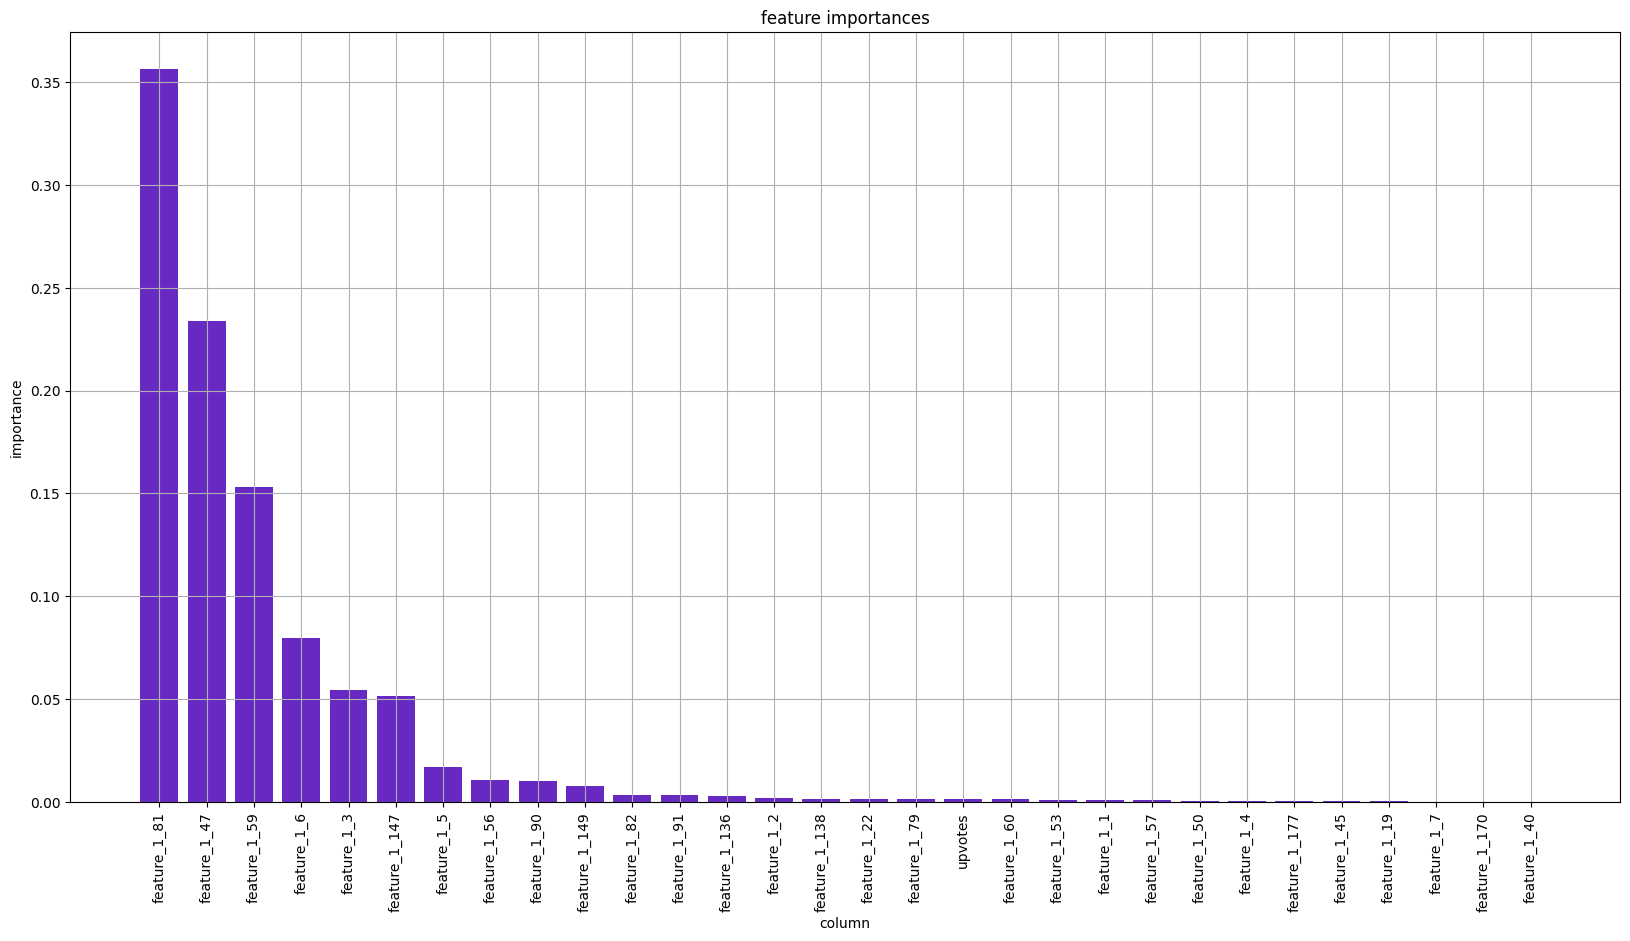

In [15]:
names, importances = pipe.features.importances(target_num=0)

plt.subplots(figsize=(20, 10))

plt.bar(names[:30], importances[:30], color='#6829c2')

plt.title("feature importances")
plt.grid(True)
plt.xlabel("column")
plt.ylabel("importance")
plt.xticks(rotation='vertical')

plt.show()

In [16]:
pipe.features.to_sql().find(names[0])[0]

```sql
DROP TABLE IF EXISTS "FEATURE_1_81";

CREATE TABLE "FEATURE_1_81" AS
SELECT SUM( t2."score" ) AS "feature_1_81",
       t1.rowid AS rownum
FROM "USERS__STAGING_TABLE_1" t1
INNER JOIN "POSTS__STAGING_TABLE_5" t2
ON t1."id" = t2."owneruserid"
WHERE t2."posttypeid" = '2'
GROUP BY t1.rowid;
```

The most important feature predictive of a user's reputation is the sum of the scores of his or her posts that of a specific type type.

In [17]:
pipe.features.to_sql().find(names[1])[0]

```sql
DROP TABLE IF EXISTS "FEATURE_1_47";

CREATE TABLE "FEATURE_1_47" AS
SELECT SUM( t2."score" ) AS "feature_1_47",
       t1.rowid AS rownum
FROM "USERS__STAGING_TABLE_1" t1
INNER JOIN "POSTS__STAGING_TABLE_5" t2
ON t1."id" = t2."owneruserid"
GROUP BY t1.rowid;
```

The second most important feature predictive of a user's reputation is the sum of the scores of all of his or her posts.

In [18]:
getml.engine.shutdown()

Shutting down the getML Engine...

Done.

### 8. Conclusion

This notebook showcases the strength and limitations of getML's FastProp. By diligently devising the datamodel, we enable FastProp to identify potent features which the XGBoost regressor uses for a prediction model. Yet, we are cognizant of the challenges that non-linear problems pose to a proposionalization based feature learner such as FastProp. More advanced tools may be suitable to capture more complexity, such as getML's [RelMT](https://getml.com/latest/user_guide/concepts/feature_engineering/#feature-engineering-algorithms-relmt) algorithm.